# # Fixed Risk Position Sizing Strategy
# ## Advanced Futures Trading Strategies - Implementation Guide
# 
# This notebook demonstrates the volatility-targeting position sizing strategy that dynamically adjusts contract sizes based on:
# - Current market volatility
# - Risk constraints (margin, leverage, Kelly criterion)
# - Capital allocation (fixed vs. compounding)
# 
# ## 📋 Table of Contents
# 1. [Setup & Imports](#setup)
# 2. [Use Case 1: Fixed vs. Current Capital](#usecase1)
# 3. [Use Case 2: Risk Target Sensitivity](#usecase2)
# 4. [Use Case 3: Volatility Window Comparison](#usecase3)
# 5. [Use Case 4: Margin & Leverage Constraints](#usecase4)
# 6. [Use Case 5: Multi-Asset Comparison](#usecase5)
# 7. [Position Sizing Analysis](#analysis)
# 8. [Risk Metrics Deep Dive](#metrics)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
# Import our modules
from src import (
    load_simple_price_csv,
    FixedRiskPositionStrategy,
    BuyAndHoldStrategy,
    VectorizedEngine,
    plot_results
)

In [2]:
# Configure matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Create outputs directory
Path("outputs/fixed_risk_strategy").mkdir(parents=True, exist_ok=True)

print("✅ All imports successful")


✅ All imports successful


# ## 2. Load Sample Data

In [3]:
data = load_simple_price_csv("data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-06-16 10:56:20.204 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-06-16 10:56:20.231 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


# ## 3. Use Case 1: Fixed vs. Current Capital <a id="usecase1"></a>
# 
# Compare two capital allocation modes:
# - **Fixed Capital**: Position size based on initial capital only (stable risk)
# - **Current Capital**: Position size scales with equity (compounding)

# %%

In [4]:
# Configuration
INITIAL_CAPITAL = 100_000
RISK_TARGET = 0.20  # 20% annualized volatility
VOLATILITY_WINDOW = 252  # yearly
MULTIPLIER = 1.0  # For stocks/spot assets

# Strategy 1: Fixed Capital (No Compounding)
strategy_fixed = FixedRiskPositionStrategy(
    initial_capital=INITIAL_CAPITAL,
    risk_target=RISK_TARGET,
    volatility_window=VOLATILITY_WINDOW,
    multiplier=MULTIPLIER,
    use_fixed_capital=True,  # ← Always use initial capital
    expected_sharpe=0.5,
    min_contracts=1,
    max_contracts=20
)

# Strategy 2: Current Capital (Compounding)
strategy_compound = FixedRiskPositionStrategy(
    initial_capital=INITIAL_CAPITAL,
    risk_target=RISK_TARGET,
    volatility_window=VOLATILITY_WINDOW,
    multiplier=MULTIPLIER,
    use_fixed_capital=False,  # ← Use running equity
    expected_sharpe=0.5,
    min_contracts=1,
    max_contracts=20
)

# Buy & Hold baseline
strategy_bh = BuyAndHoldStrategy(position_size=1.0)


In [5]:
# Run backtests
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,
    point_value=MULTIPLIER,
    commission_rate=0.001,  # 0.1%
    slippage_rate=0.0005    # 0.05%
)

print("🔄 Running backtests...")
result_fixed = engine.run(strategy_fixed, data, strategy_name="Fixed Capital", ticker="MCFTR")
result_compound = engine.run(strategy_compound, data, strategy_name="Current Capital", ticker="MCFTR")
result_bh = engine.run(strategy_bh, data, strategy_name="Buy & Hold", ticker="MCFTR")

print("✅ Backtests complete")


🔄 Running backtests...
✅ Backtests complete


# ### 3.1 Compare Results

In [6]:
# Print summaries
print("=" * 80)
print("FIXED CAPITAL STRATEGY")
print("=" * 80)
result_fixed.print_summary()

print("\n" + "=" * 80)
print("CURRENT CAPITAL (COMPOUNDING) STRATEGY")
print("=" * 80)
result_compound.print_summary()

print("\n" + "=" * 80)
print("BUY & HOLD BASELINE")
print("=" * 80)
result_bh.print_summary()


FIXED CAPITAL STRATEGY
┌──────────────────────────────────────────────────────────────────────
│ Strategy: Fixed Capital                            │ MCFTR                    │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +3.5% │
│ Average drawdown                         │                    -1.5% │
│ Maximum drawdown                         │                   -27.1% │
│ Annualised standard deviation            │                     8.4% │
│ Sharpe ratio                             │                     0.42 │
│ Skew                                     │                    -3.23 │
│ Lower tail                               │                     2.17 │
│ Upper tail                               │                     1.48 │
└──────────────────────────────────────────────────────────────────────┘

CURRENT CAPITAL (COMPOUNDING

# ### 3.2 Visualize Equity Curves

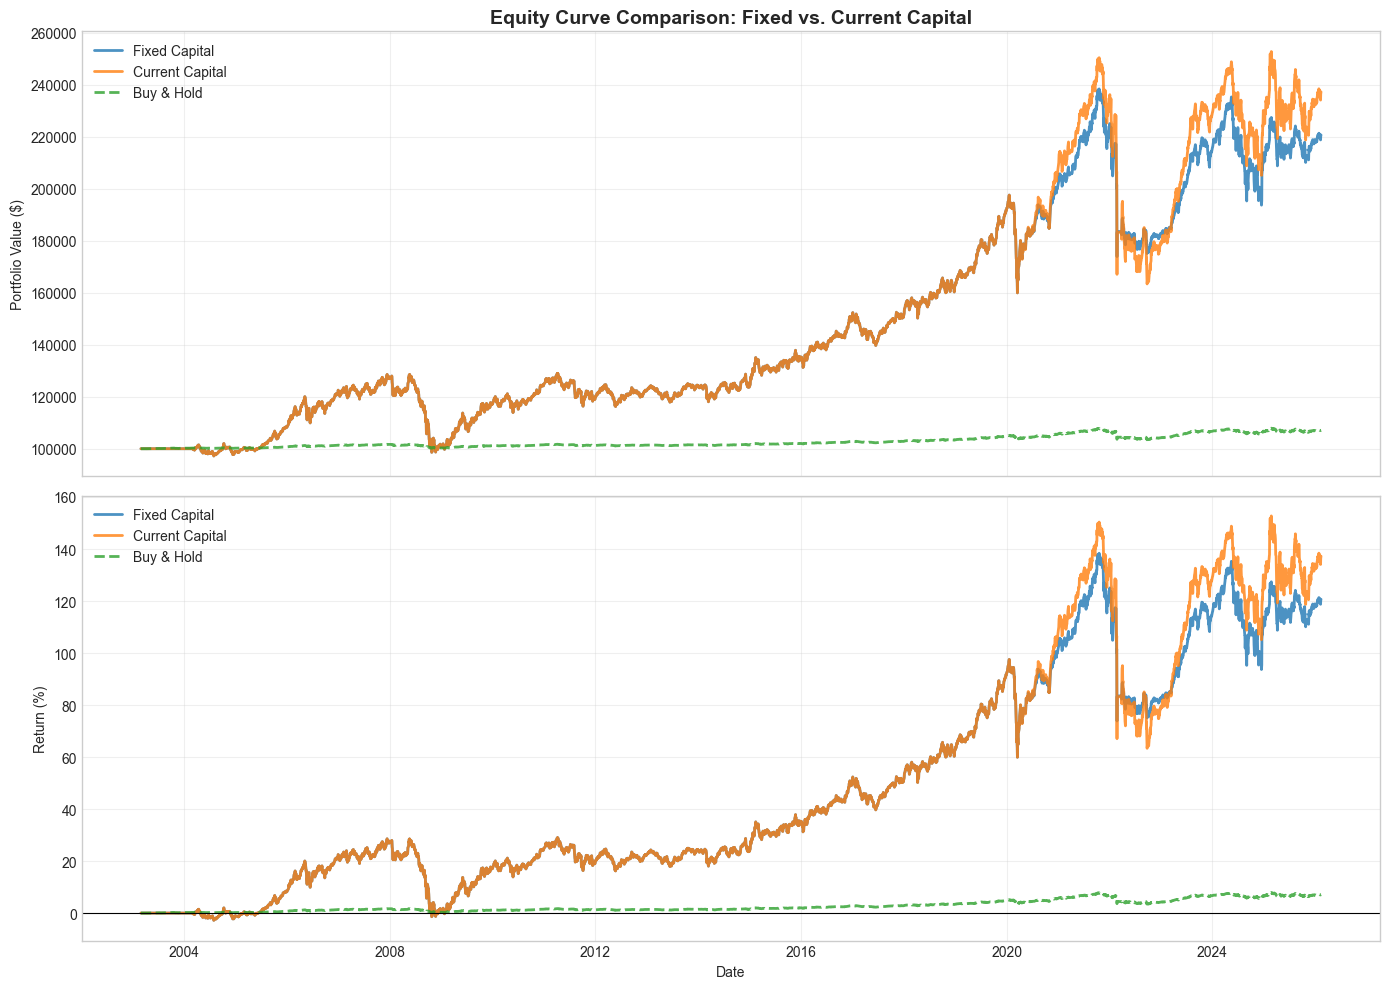

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: Absolute equity
axes[0].plot(result_fixed.equity.index, result_fixed.equity, 
             label="Fixed Capital", linewidth=2, alpha=0.8)
axes[0].plot(result_compound.equity.index, result_compound.equity, 
             label="Current Capital", linewidth=2, alpha=0.8)
axes[0].plot(result_bh.equity.index, result_bh.equity, 
             label="Buy & Hold", linewidth=2, alpha=0.8, linestyle='--')
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].set_title("Equity Curve Comparison: Fixed vs. Current Capital", fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Panel 2: Percentage returns
initial = INITIAL_CAPITAL
axes[1].plot(result_fixed.equity.index, (result_fixed.equity / initial - 1) * 100,
             label="Fixed Capital", linewidth=2, alpha=0.8)
axes[1].plot(result_compound.equity.index, (result_compound.equity / initial - 1) * 100,
             label="Current Capital", linewidth=2, alpha=0.8)
axes[1].plot(result_bh.equity.index, (result_bh.equity / initial - 1) * 100,
             label="Buy & Hold", linewidth=2, alpha=0.8, linestyle='--')
axes[1].set_ylabel("Return (%)")
axes[1].set_xlabel("Date")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/fixed_risk_strategy/01_capital_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ### 3.3 Key Insights

In [8]:
# Calculate comparison metrics
comparison = pd.DataFrame({
    'Metric': ['Total Return (%)', 'CAGR (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Avg Drawdown (%)'],
    'Fixed Capital': [
        result_fixed.metrics['total_return_pct'],
        result_fixed.metrics['cagr_pct'],
        result_fixed.metrics['sharpe_ratio'],
        result_fixed.metrics['max_drawdown_pct'],
        result_fixed.metrics['avg_drawdown_pct']
    ],
    'Current Capital': [
        result_compound.metrics['total_return_pct'],
        result_compound.metrics['cagr_pct'],
        result_compound.metrics['sharpe_ratio'],
        result_compound.metrics['max_drawdown_pct'],
        result_compound.metrics['avg_drawdown_pct']
    ],
    'Buy & Hold': [
        result_bh.metrics['total_return_pct'],
        result_bh.metrics['cagr_pct'],
        result_bh.metrics['sharpe_ratio'],
        result_bh.metrics['max_drawdown_pct'],
        result_bh.metrics['avg_drawdown_pct']
    ]
})

display(comparison.set_index('Metric'))

,Fixed Capital,Current Capital,Buy & Hold
Metric,,,
Total Return (%),120.66,137.25,7.13
CAGR (%),3.54,3.87,0.30
Sharpe Ratio,0.42,0.39,0.35
Max Drawdown (%),-27.06,-34.75,-4.04
Avg Drawdown (%),-1.53,-1.68,-0.12


# ## 4. Use Case 2: Risk Target Sensitivity
# 
# Test different risk targets (τ) to find optimal volatility exposure

In [9]:
risk_targets = [0.10, 0.15, 0.20, 0.25, 0.30]  # 10% to 30% annualized vol
results_risk = []

print("🔬 Testing risk target sensitivity...")

for tau in risk_targets:
    strat = FixedRiskPositionStrategy(
        initial_capital=INITIAL_CAPITAL,
        risk_target=tau,
        volatility_window=VOLATILITY_WINDOW,
        multiplier=MULTIPLIER,
        use_fixed_capital=True,
        expected_sharpe=0.5,
        min_contracts=1,
        max_contracts=20
    )
    
    result = engine.run(strat, data, strategy_name=f"Risk Target {tau*100:.0f}%", ticker="SPX")
    results_risk.append(result)
    
    print(f"  τ={tau*100:5.1f}% → Return: {result.metrics['total_return_pct']:6.2f}%, "
          f"Sharpe: {result.metrics['sharpe_ratio']:.2f}, "
          f"Max DD: {result.metrics['max_drawdown_pct']:.1f}%")


🔬 Testing risk target sensitivity...
  τ= 10.0% → Return:  91.47%, Sharpe: 0.43, Max DD: -23.1%
  τ= 15.0% → Return: 104.28%, Sharpe: 0.42, Max DD: -23.3%
  τ= 20.0% → Return: 120.66%, Sharpe: 0.42, Max DD: -27.1%
  τ= 25.0% → Return: 129.26%, Sharpe: 0.41, Max DD: -31.3%
  τ= 30.0% → Return: 129.26%, Sharpe: 0.41, Max DD: -31.3%


# ### 4.1 Risk-Return Profile

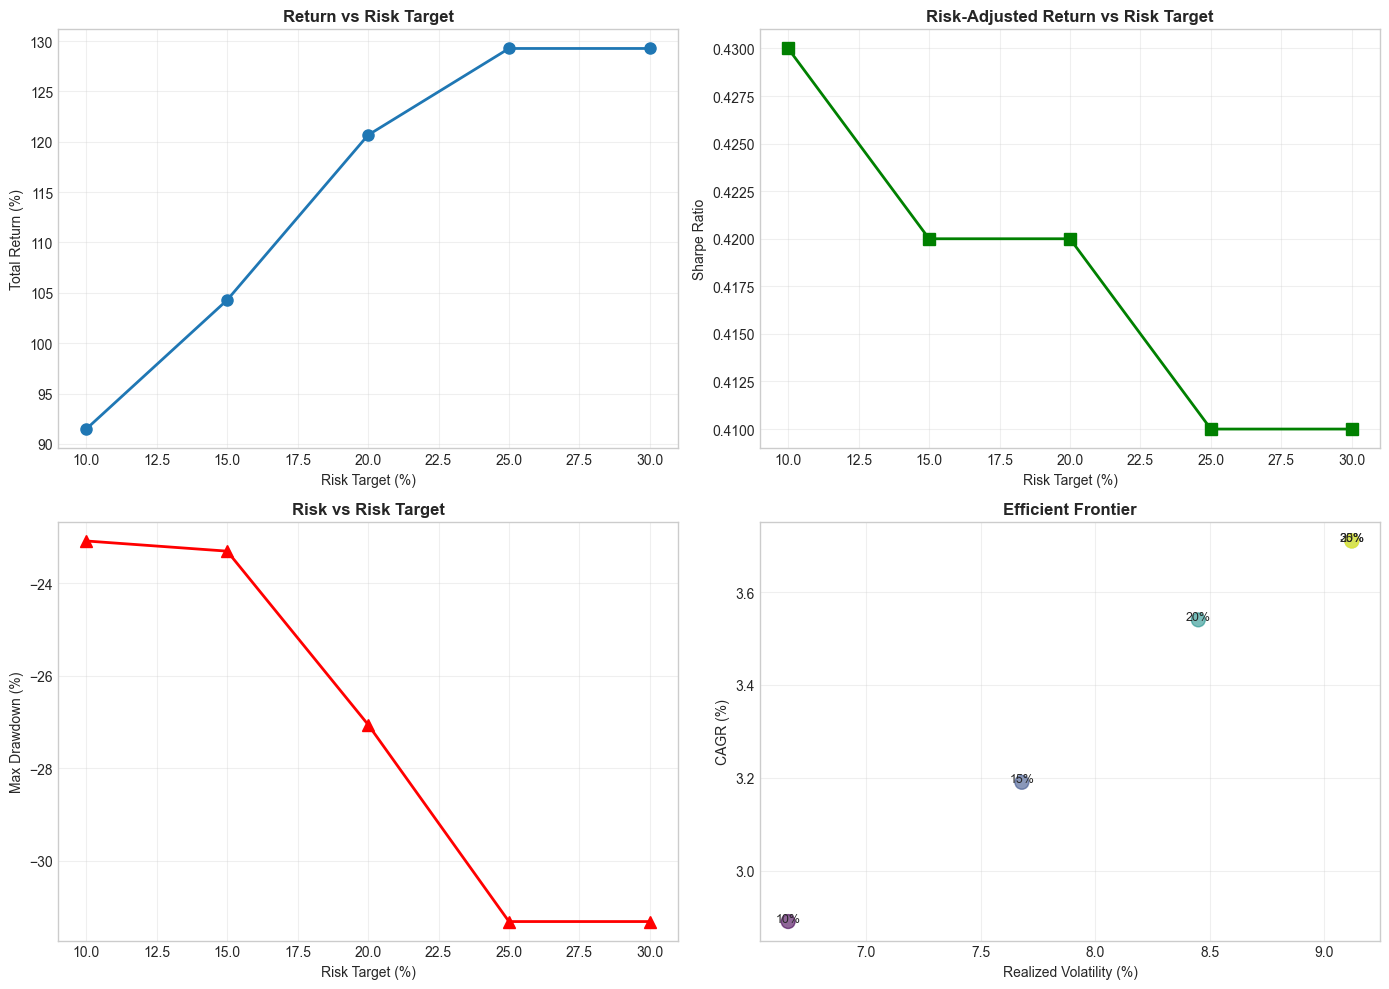

,Risk Target (%),Total Return (%),CAGR (%),Sharpe Ratio,Max Drawdown (%),Volatility (%)
0,10.0,91.47,2.89,0.43,-23.09,6.66
1,15.0,104.28,3.19,0.42,-23.31,7.68
2,20.0,120.66,3.54,0.42,-27.06,8.45
3,25.0,129.26,3.71,0.41,-31.32,9.12
4,30.0,129.26,3.71,0.41,-31.32,9.12


In [10]:
# Extract metrics
risk_metrics = pd.DataFrame({
    'Risk Target (%)': [t * 100 for t in risk_targets],
    'Total Return (%)': [r.metrics['total_return_pct'] for r in results_risk],
    'CAGR (%)': [r.metrics['cagr_pct'] for r in results_risk],
    'Sharpe Ratio': [r.metrics['sharpe_ratio'] for r in results_risk],
    'Max Drawdown (%)': [r.metrics['max_drawdown_pct'] for r in results_risk],
    'Volatility (%)': [r.metrics['annual_volatility_pct'] for r in results_risk]
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Return vs Risk Target
axes[0, 0].plot(risk_metrics['Risk Target (%)'], risk_metrics['Total Return (%)'], 
                marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Risk Target (%)')
axes[0, 0].set_ylabel('Total Return (%)')
axes[0, 0].set_title('Return vs Risk Target', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Sharpe vs Risk Target
axes[0, 1].plot(risk_metrics['Risk Target (%)'], risk_metrics['Sharpe Ratio'], 
                marker='s', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Risk Target (%)')
axes[0, 1].set_ylabel('Sharpe Ratio')
axes[0, 1].set_title('Risk-Adjusted Return vs Risk Target', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Max Drawdown vs Risk Target
axes[1, 0].plot(risk_metrics['Risk Target (%)'], risk_metrics['Max Drawdown (%)'], 
                marker='^', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('Risk Target (%)')
axes[1, 0].set_ylabel('Max Drawdown (%)')
axes[1, 0].set_title('Risk vs Risk Target', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Efficient Frontier (Return vs Volatility)
axes[1, 1].scatter(risk_metrics['Volatility (%)'], risk_metrics['CAGR (%)'], 
                   s=100, c=risk_metrics['Risk Target (%)'], cmap='viridis', alpha=0.6)
for i, row in risk_metrics.iterrows():
    axes[1, 1].annotate(f"{row['Risk Target (%)']:.0f}%", 
                       (row['Volatility (%)'], row['CAGR (%)']),
                       fontsize=9, ha='center')
axes[1, 1].set_xlabel('Realized Volatility (%)')
axes[1, 1].set_ylabel('CAGR (%)')
axes[1, 1].set_title('Efficient Frontier', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/fixed_risk_strategy/02_risk_target_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()

# Display table
display(risk_metrics.round(2))

# ## 5. Use Case 3: Volatility Window Comparison
# 
# Test different lookback periods for volatility estimation

In [11]:
vol_windows = [21, 63, 126, 252]  # 1 month, 3 months, 6 months, 1 year
results_window = []

print("🔬 Testing volatility window sensitivity...")

for window in vol_windows:
    strat = FixedRiskPositionStrategy(
        initial_capital=INITIAL_CAPITAL,
        risk_target=RISK_TARGET,
        volatility_window=window,
        multiplier=MULTIPLIER,
        use_fixed_capital=True,
        expected_sharpe=0.5,
        min_contracts=1,
        max_contracts=20
    )
    
    result = engine.run(strat, data, strategy_name=f"Vol Window {window}d", ticker="SPX")
    results_window.append(result)
    
    label = f"{window:3d}d ({window/21:4.1f} months)"
    print(f"  Window {label} → Return: {result.metrics['total_return_pct']:6.2f}%, "
          f"Sharpe: {result.metrics['sharpe_ratio']:.2f}")


🔬 Testing volatility window sensitivity...
  Window  21d ( 1.0 months) → Return: 157.76%, Sharpe: 0.59
  Window  63d ( 3.0 months) → Return: 162.44%, Sharpe: 0.58
  Window 126d ( 6.0 months) → Return: 151.22%, Sharpe: 0.53
  Window 252d (12.0 months) → Return: 120.66%, Sharpe: 0.42


# ### 5.1 Window Sensitivity Analysis

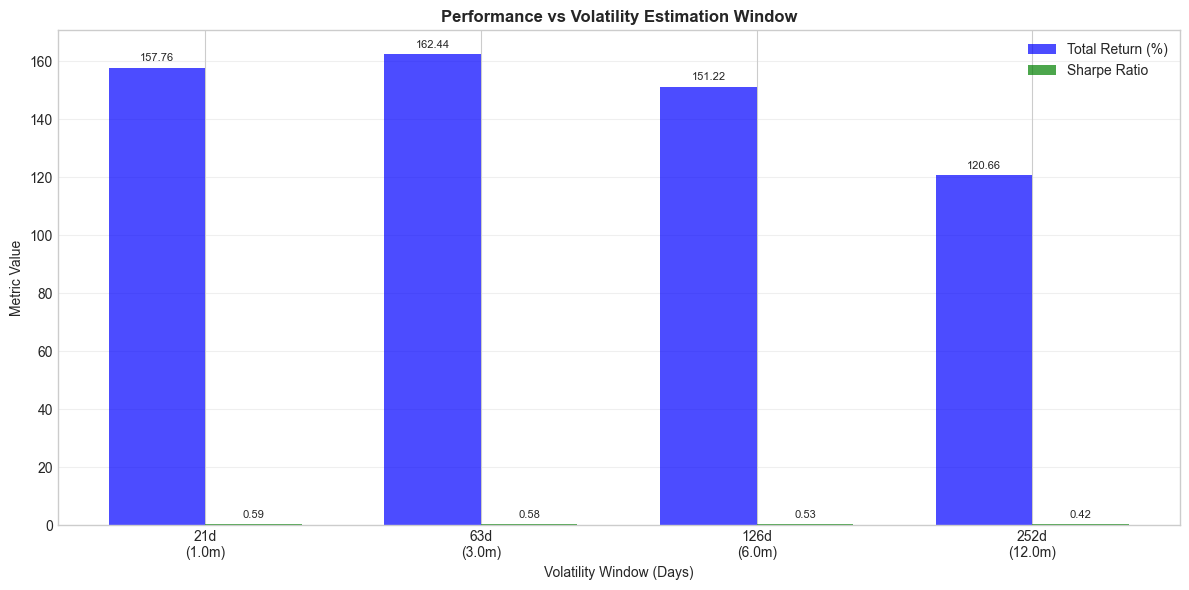

,Window (days),Window (months),Total Return (%),Sharpe Ratio,Max Drawdown (%)
0,21,1.0,157.76,0.59,-20.44
1,63,3.0,162.44,0.58,-22.65
2,126,6.0,151.22,0.53,-23.15
3,252,12.0,120.66,0.42,-27.06


In [12]:
window_metrics = pd.DataFrame({
    'Window (days)': vol_windows,
    'Window (months)': [w/21 for w in vol_windows],
    'Total Return (%)': [r.metrics['total_return_pct'] for r in results_window],
    'Sharpe Ratio': [r.metrics['sharpe_ratio'] for r in results_window],
    'Max Drawdown (%)': [r.metrics['max_drawdown_pct'] for r in results_window]
})

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(vol_windows))
width = 0.35

bars1 = ax.bar(x - width/2, window_metrics['Total Return (%)'], width, label='Total Return (%)', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, window_metrics['Sharpe Ratio'], width, label='Sharpe Ratio', color='green', alpha=0.7)

ax.set_xlabel('Volatility Window (Days)')
ax.set_ylabel('Metric Value')
ax.set_title('Performance vs Volatility Estimation Window', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{w}d\n({w/21:.1f}m)' for w in vol_windows])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("outputs/fixed_risk_strategy/03_window_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()

display(window_metrics.round(2))


# ## 6. Use Case 4: Margin & Leverage Constraints <a id="usecase4"></a>
# 
# Demonstrate how margin requirements limit position sizing

In [13]:
# Test with different margin levels
margin_scenarios = {
    'No Margin Constraint': None,
    'Low Margin ($5k/contract)': 5_000,
    'Medium Margin ($12k/contract)': 12_000,
    'High Margin ($20k/contract)': 20_000
}

results_margin = []

print("🔬 Testing margin constraint scenarios...")

for scenario_name, margin in margin_scenarios.items():
    strat = FixedRiskPositionStrategy(
        initial_capital=INITIAL_CAPITAL,
        risk_target=RISK_TARGET,
        volatility_window=VOLATILITY_WINDOW,
        multiplier=MULTIPLIER,
        use_fixed_capital=True,
        margin_per_contract=margin,
        max_capital_loss=0.50,
        expected_worst_return=0.10,
        expected_sharpe=0.5,
        min_contracts=1,
        max_contracts=50  # High max to see constraint effect
    )
    
    result = engine.run(strat, data, strategy_name=scenario_name, ticker="SPX")
    results_margin.append(result)
    
    print(f"  {scenario_name:30s} → Return: {result.metrics['total_return_pct']:6.2f}%, "
          f"Contracts: {strat.last_position:.0f}")


🔬 Testing margin constraint scenarios...
  No Margin Constraint           → Return: 197.48%, Contracts: 12
  Low Margin ($5k/contract)      → Return: 120.66%, Contracts: 12
  Medium Margin ($12k/contract)  → Return:  54.90%, Contracts: 8
  High Margin ($20k/contract)    → Return:  34.31%, Contracts: 5


# ## 7. Position Sizing Analysis <a id="analysis"></a>
# 
# Deep dive into how position sizes change over time

# ### 7.1 Position Size Time Series

CURRENT POSITION DETAILS
current_price                 : 7,470.19
current_volatility            : 0.22
risk_target                   : 0.20
effective_risk                : 0.20
capital_used                  : 100000
use_fixed_capital             : True
num_contracts                 : 12.00
notional_value                : 89,642.28
risk_contribution             : 0.20
margin_per_contract           : None
multiplier                    : 1.00


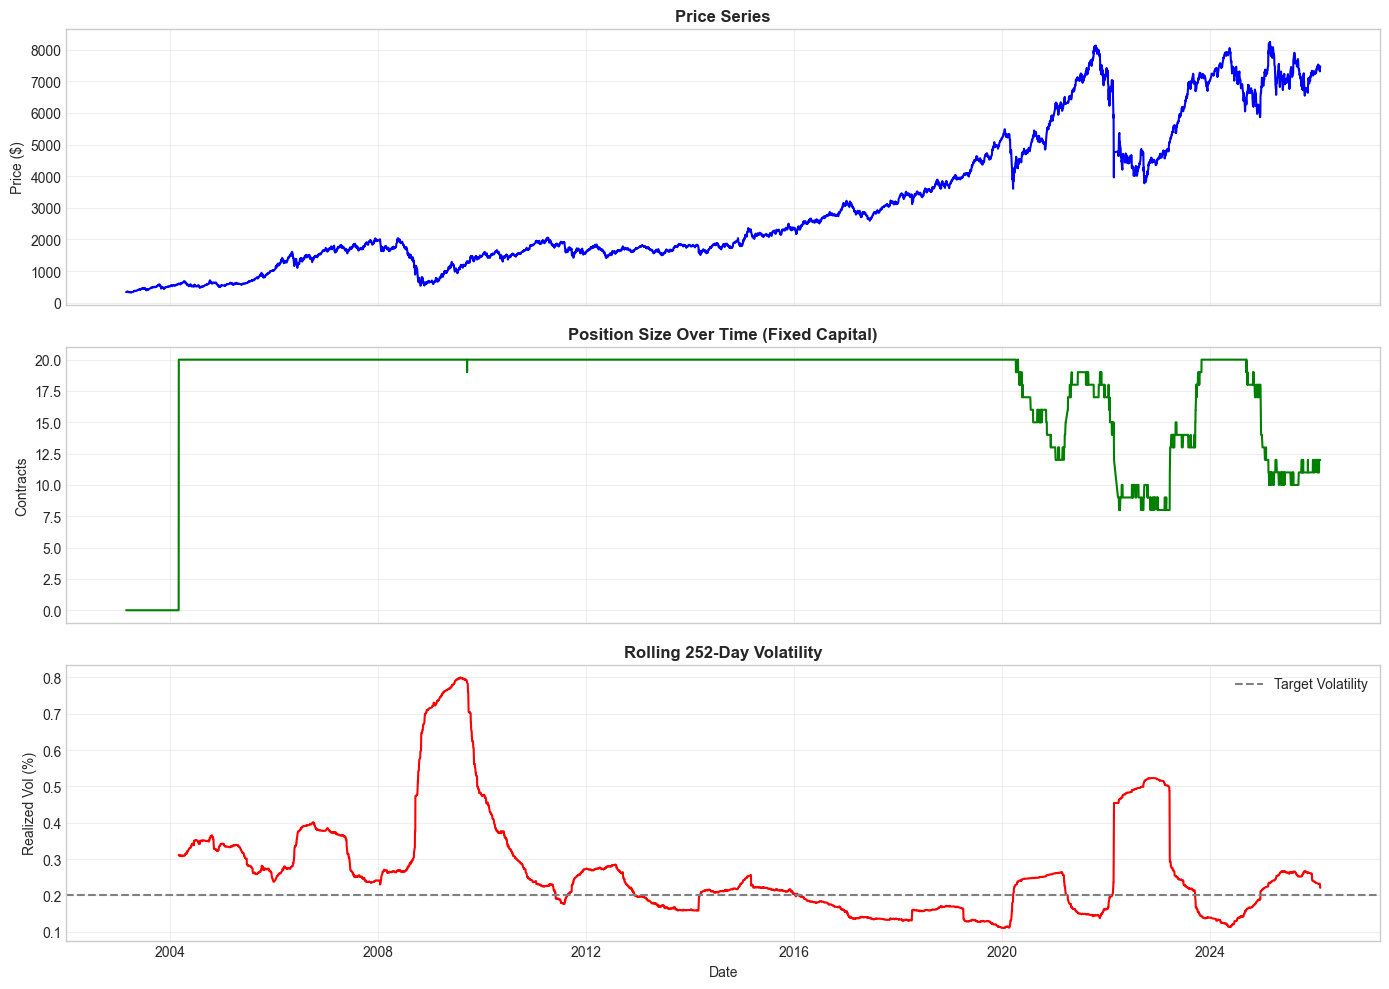

In [14]:
# Get detailed position info
info = strategy_fixed.get_detailed_info(data, capital=INITIAL_CAPITAL)

print("=" * 80)
print("CURRENT POSITION DETAILS")
print("=" * 80)
for key, value in info.items():
    if isinstance(value, float):
        print(f"{key:30s}: {value:,.2f}")
    else:
        print(f"{key:30s}: {value}")

# %% [markdown]
# ### 7.1 Position Size Time Series

# %%
# Plot position sizes over time
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Price
axes[0].plot(data.index, data['close'], linewidth=1.5, color='blue')
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Price Series', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Panel 2: Positions
axes[1].plot(result_fixed.positions.index, result_fixed.positions, 
             linewidth=1.5, color='green')
axes[1].set_ylabel('Contracts')
axes[1].set_title('Position Size Over Time (Fixed Capital)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Panel 3: Volatility
volatility = data['close'].pct_change().rolling(VOLATILITY_WINDOW).std() * np.sqrt(252)
axes[2].plot(volatility.index, volatility, linewidth=1.5, color='red')
axes[2].axhline(RISK_TARGET, color='gray', linestyle='--', label='Target Volatility')
axes[2].set_ylabel('Realized Vol (%)')
axes[2].set_xlabel('Date')
axes[2].set_title(f'Rolling {VOLATILITY_WINDOW}-Day Volatility', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/fixed_risk_strategy/04_position_analysis.png", dpi=150, bbox_inches='tight')
plt.show()


# ### 7.2 Position Size Distribution

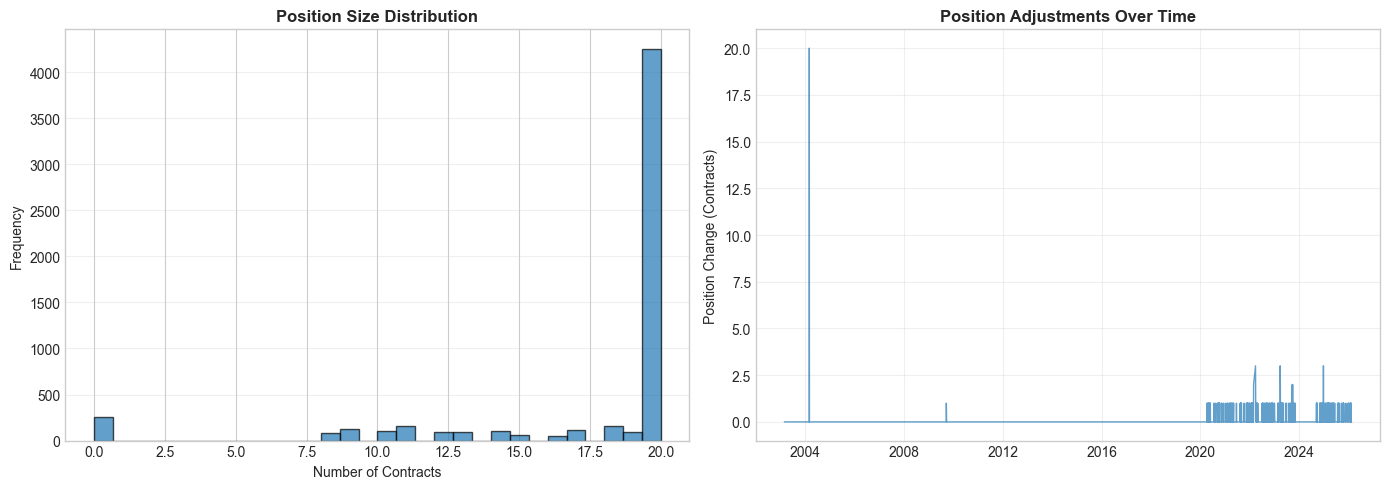

COMPREHENSIVE RISK METRICS
┌──────────────────────────────────────────────────────────────────────
│ Strategy: Fixed Capital                            │ MCFTR                    │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +3.5% │
│ Average drawdown                         │                    -1.5% │
│ Maximum drawdown                         │                   -27.1% │
│ Annualised standard deviation            │                     8.4% │
│ Sharpe ratio                             │                     0.42 │
│ Skew                                     │                    -3.23 │
│ Lower tail                               │                     2.17 │
│ Upper tail                               │                     1.48 │
└──────────────────────────────────────────────────────────────────────┘

TAIL RISK ANALYSIS
Lower

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\mpl_plots.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


📊 Plot saved to: outputs/fixed_risk_strategy/06_equity_absolute.png
📊 Plot saved to: outputs/fixed_risk_strategy/06_equity_percentage.png
📊 Plot saved to: outputs/fixed_risk_strategy/07_compound_equity.png

✅ All visualizations saved to outputs/fixed_risk_strategy/


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(result_fixed.positions.dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Contracts')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Position Size Distribution', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Time series of position changes
pos_changes = result_fixed.positions.diff().abs()
axes[1].plot(pos_changes.index, pos_changes, linewidth=1, alpha=0.7)
axes[1].set_ylabel('Position Change (Contracts)')
axes[1].set_title('Position Adjustments Over Time', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/fixed_risk_strategy/05_position_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 8. Risk Metrics Deep Dive <a id="metrics"></a>

# %%
# Comprehensive risk analysis
print("=" * 80)
print("COMPREHENSIVE RISK METRICS")
print("=" * 80)

result_fixed.print_summary()

# Additional analysis
print("\n" + "=" * 80)
print("TAIL RISK ANALYSIS")
print("=" * 80)
print(f"Lower Tail Ratio: {result_fixed.metrics['lower_tail']:.3f}")
print(f"Upper Tail Ratio: {result_fixed.metrics['upper_tail']:.3f}")
print(f"Combined Tail Risk: {result_fixed.metrics['tail_risk']:.3f}")
print("\nInterpretation:")
print(f"  • Lower tail > 1.0: Extreme losses are {'more' if result_fixed.metrics['lower_tail'] > 1 else 'less'} severe than normal")
print(f"  • Upper tail > 1.0: Extreme gains are {'more' if result_fixed.metrics['upper_tail'] > 1 else 'less'} severe than normal")

# %% [markdown]
# ## 9. Save Results

# %%
# Save all plots
plot_results(result_fixed, save_to_file=True, plot_pct=False, 
             output_path="outputs/fixed_risk_strategy/06_equity_absolute.png")
plot_results(result_fixed, save_to_file=True, plot_pct=True,
             output_path="outputs/fixed_risk_strategy/06_equity_percentage.png")

plot_results(result_compound, save_to_file=True, plot_pct=True,
             output_path="outputs/fixed_risk_strategy/07_compound_equity.png")

print("\n✅ All visualizations saved to outputs/fixed_risk_strategy/")


# ## 10. Summary & Recommendations
# ### Key Findings
# 
# 1. **Fixed vs. Current Capital**:
#    - Fixed capital provides stable, predictable position sizing
#    - Current capital compounds gains but increases risk during drawdowns
#    - Choose based on risk tolerance and capital stability requirements
# 
# 2. **Risk Target Selection**:
#    - Higher τ → Higher returns but also higher drawdowns
#    - Optimal τ typically between 15-25% for most strategies
#    - Test across multiple market regimes before committing
# 
# 3. **Volatility Window**:
#    - Shorter windows (21-63 days) react faster to vol changes
#    - Longer windows (126-252 days) provide smoother position sizing
#    - 63 days (3 months) is a good balance for most strategies
# 
# 4. **Margin Constraints**:
#    - Always specify realistic margin requirements
#    - Prevents over-leveraging during low-volatility periods
#    - Critical for futures trading
# 
# ### Next Steps
# 
# 1. **Parameter Optimization**: Use walk-forward analysis to find optimal τ and window
# 2. **Multi-Asset Testing**: Apply to different instruments (futures, stocks, crypto)
# 3. **Regime Analysis**: Test performance in bull vs. bear markets
# 4. **Live Testing**: Paper trade with conservative parameters before live deployment
# 
# ---